In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

df = pd.read_csv("E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\data\\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv", skipinitialspace=True)
df.head()


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225745 non-null  int64  
 1   Flow Duration                225745 non-null  int64  
 2   Total Fwd Packets            225745 non-null  int64  
 3   Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets  225745 non-null  int64  
 5   Total Length of Bwd Packets  225745 non-null  int64  
 6   Fwd Packet Length Max        225745 non-null  int64  
 7   Fwd Packet Length Min        225745 non-null  int64  
 8   Fwd Packet Length Mean       225745 non-null  float64
 9   Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max        225745 non-null  int64  
 11  Bwd Packet Length Min        225745 non-null  int64  
 12  Bwd Packet Length Mean       225745 non-null  float64
 13  Bwd Packet

<Axes: xlabel='Label', ylabel='count'>

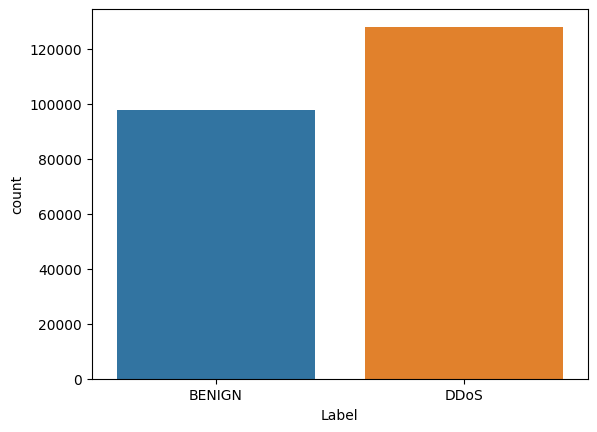

In [3]:
df.dropna(inplace=True)

sns.countplot(data=df, x = "Label", hue="Label")

In [4]:
#Random Forest Classfier
df_dummies = pd.get_dummies(df, drop_first=True)
df_dummies.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label_DDoS
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,False
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,False
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,False
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,False
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,False


In [5]:
X,y = df_dummies.drop("Label_DDoS", axis=1), df_dummies["Label_DDoS"]


# 1) Force numeric
X = X.apply(pd.to_numeric, errors="coerce")

# 2) Replace inf/-inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 3) Drop rows with any NaN in X
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

print("Any inf left in X?", np.isinf(X.to_numpy()).sum())
print("Any NaN left in X?", np.isnan(X.to_numpy()).sum())
print("Clean X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

Any inf left in X? 0
Any NaN left in X? 0
Clean X shape: (225711, 78)


((180568, 78), (45143, 78))

In [6]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)
y_pred

array([False, False, False, ..., False, False,  True], shape=(45143,))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00     19419
        True       1.00      1.00      1.00     25724

    accuracy                           1.00     45143
   macro avg       1.00      1.00      1.00     45143
weighted avg       1.00      1.00      1.00     45143



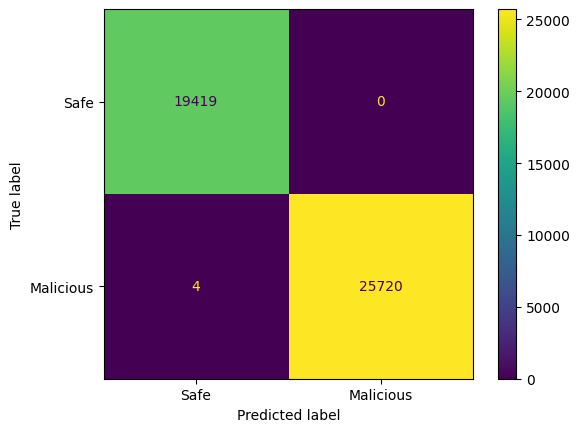

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print(classification_report(y_test, y_pred))

cm =confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Safe", "Malicious"]).plot()

In [8]:
model_rf.feature_importances_.shape, X_train.shape

((78,), (180568, 78))

In [12]:
import joblib

joblib.dump(model_rf, "E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\models\\rf_ids_v1.joblib")

['E:\\Project Portfolio\\Dissertation\\Final-Year-IDS\\models\\rf_ids_v1.joblib']